In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('advertising.csv')

In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (1000, 10)

Missing Values:
 Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


In [4]:
X = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y = df['Clicked on Ad']

In [5]:
print("\nX Head:\n", X.head())
print("\ny Head:\n", y.head())


X Head:
    Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  Male
0                     68.95   35     61833.90                256.09     0
1                     80.23   31     68441.85                193.77     1
2                     69.47   26     59785.94                236.50     0
3                     74.15   29     54806.18                245.89     1
4                     68.37   35     73889.99                225.58     0

y Head:
 0    0
1    0
2    0
3    0
4    0
Name: Clicked on Ad, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print("Number of training records:", len(X_train))
print("Number of testing records:", len(X_test))

Number of training records: 800
Number of testing records: 200


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
class_results = pd.DataFrame({"Actual Class": y_test.values, "Predicted Class": y_pred})
print("\nFirst 10 Predictions:\n", class_results.head(10))


First 10 Predictions:
    Actual Class  Predicted Class
0             1                1
1             1                1
2             1                1
3             1                1
4             0                0
5             0                0
6             0                0
7             1                1
8             0                0
9             1                1


In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print(f"Accuracy (%): {accuracy * 100:.2f}%")


Accuracy: 0.96
Accuracy (%): 96.00%


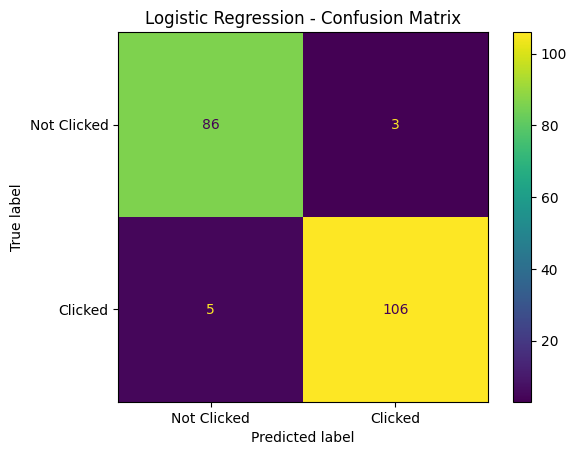

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Clicked', 'Clicked'])
disp.plot()

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [16]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

